<a href="https://colab.research.google.com/github/Tinapie14/dal-sacro-all-umano/blob/main/Dal_sacro_all'umano_la_Storia_dell'Arte_letta_in_chiave_digitale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Esame di Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)


# ***Dal sacro all'umano: la Storia dell'Arte letta in chiave digitale***

# 1. Introduzione

In questo progetto effettuiamo un'analisi dei dati (esplorativa e esplicativa) di un dataset storico-artistico, contenente opere d'arte realizzate tra il 1200 e il 2000.

## 1.1. Obiettivo
Il lavoro consiste nell’esplorazione, nella pulizia e nell’analisi del set di dati. Verranno esaminate alcune categorie presenti nel dataset, come i contenuti, le date di creazione, i generi e i movimenti artistici, analizzandole nel dettaglio per rispondere alle domande di ricerca individuate.


## 1.2. Dati utilizzati
I dati in input sono costituiti da un file CSV di 523+ KB scaricato da una repository GitHub del corso di studi (https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv).


| Variabile | Tipo |	Definizione | Esempio |
| :------- | :--- | :--------- | :------ |
| id       |	str | ID dell'opera | 	http://www.wikidata.org/entity/Q428274 |
| titolo | str | Titolo dell'opera | Ritratto di Fedra Inghirami, detto Fedra |
| artisti |	str |	Artista dell'opera |	Raffaello Sanzio (maschio) |
| data_creazione |	int |	Anno di realizzazione |	1510 |
| generi | str | Genere pittorico |	ritratto |
| luoghi |	str | Dove è stata l'opera | Galleria Palatina |
| collezioni | str |	Collezione di appartenenza | Galleria Palatina |
| contenuti |	str |	Elementi presenti |	libro; carta; scrittura; strabismo; posizione seduta; scrivania; calamaio |
| movimenti | str | Periodo/corrente artistica |	Alto Rinascimento |
| soggetti | str | Soggetti dell'opera | Tommaso Inghirami |
| altezza | float | Altezza dell'opera | 91.0 |
| larghezza | float | Larghezza dell'opera | 61.0 |



## 1.3. Organizzazione
Il progetto è stato sviluppato in un ambiente Google Colab utilizzando il linguaggio di programmazione Python. Lo strumento principale utilizzato per la manipolazione, l'analisi e la visualizzazione dei dati è la libreria Pandas.

Le operazioni includono:

* Caricamento e ispezione dei dati (pd.read_csv, df.shape, df.info(), df.head(), df.tail(), df.describe());
* Bonifica e normalizzazione dei dati (valori di misurazione sbagliati, id_number considerati come stringhe e non come Int64);
* Analisi esplorativa e visualizzazioni tramite grafici a barre (plot.barh()), a linee (plot.line()), a torta (plot.pie()) e heatmap;
* Analisi esplicativa focalizzata sulle diverse categorie proposte per rispondere alle domande di ricerca individuate.
* Sono state utilizzate anche le librerie Matplotlib e Seaborn per la visualizzazione dei risultati.


##1.4. Preservazione
Nel rispetto e osservanza dei principi FAIR (reversibilità, accessibilità, interoperabilità e riutilizzabilità), i dati di output sono stati archiviati:

su *Github*, con la licenza [CC0 1.0 Universal](https://creativecommons.org/publicdomain/zero/1.0/);

su *Zotero*, con il DOI.

##1.5. Accesso e Utilizzo
I dati di input sono rilasciati sotto licenza [CC0 1.0 Universal](https://creativecommons.org/publicdomain/zero/1.0/).

Il codice è rilasciato sotto licenza [CC0 1.0 Universal](https://creativecommons.org/publicdomain/zero/1.0/).

I dati di output sono rilasciati sotto licenza [CC0 1.0 Universal](https://creativecommons.org/publicdomain/zero/1.0/).

#2. Caricamento e ispezione

In [127]:
import pandas as pd

In [128]:
df = pd.read_csv("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv")

In [129]:
df.shape

(2444, 12)

In [130]:
df.columns

Index(['id', 'titolo', 'artisti', 'data_creazione', 'generi', 'luoghi',
       'collezioni', 'contenuti', 'movimenti', 'soggetti', 'altezza',
       'larghezza'],
      dtype='object')

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: float64(2), object(10)
memory usage: 229.3+ KB


In [132]:
df.head()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0


In [133]:
df.tail()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0
2443,http://www.wikidata.org/entity/Q137169658,"Ritratto di fanciulla, ""Violante""",Giovanni Cariani (maschio),1600,ritratto,Galleria Estense,Galleria Estense,parapetto; donna giovane,pittura veneta; Alto Rinascimento,donna giovane,90.0,65.0


In [134]:
print(df.duplicated().value_counts())

False    2444
Name: count, dtype: int64


In [135]:
df.isnull().sum()

,0
id,0
titolo,0
artisti,285
data_creazione,966
generi,920
luoghi,82
collezioni,208
contenuti,423
movimenti,2062
soggetti,778


#3. Processamento

Grazie al comando `df.info` possiamo già notare delle stranezze dei dati.

Nello specifico:


*   Gli `id` sono `object` (sono i link di wikimedia)
*   Le `data_creazione` delle opere sono `object`


Cominciamo a "bonificare" la colonna `id`

Creiamo quindi un nuovo dataframe `df2`, duplicando la colonna `id` in modo da poter estrarre il numero.

In [136]:
df2 = df.copy()

In [137]:
df2["link"]=df2["id"]

In [138]:
df2["id_number"]= df2["id"].str.split("/").str[-1]

In [139]:
print(df2[["id", "link", "id_number"]].head())

                                       id  \
0  http://www.wikidata.org/entity/Q428274   
1  http://www.wikidata.org/entity/Q151047   
2  http://www.wikidata.org/entity/Q180632   
3  http://www.wikidata.org/entity/Q368788   
4  http://www.wikidata.org/entity/Q549847   

                                     link id_number  
0  http://www.wikidata.org/entity/Q428274   Q428274  
1  http://www.wikidata.org/entity/Q151047   Q151047  
2  http://www.wikidata.org/entity/Q180632   Q180632  
3  http://www.wikidata.org/entity/Q368788   Q368788  
4  http://www.wikidata.org/entity/Q549847   Q549847  


La colonna "id_number" è una stringa perchè contiene il prefisso Q. Dobbiamo quindi convertirla in un numero intero rimuovendo la lettera Q.

In [140]:
df2["id_number"]=df2["id_number"].str.replace("Q", "")

In [141]:
df2['id_number'] = df2.id_number.astype('Int64')

In [142]:
df2 = df2.drop(columns=['id'])

In [143]:
(df2.head())

,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,link,id_number
0,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0,http://www.wikidata.org/entity/Q428274,428274
1,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5,http://www.wikidata.org/entity/Q151047,151047
2,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0,http://www.wikidata.org/entity/Q180632,180632
3,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0,http://www.wikidata.org/entity/Q368788,368788
4,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0,http://www.wikidata.org/entity/Q549847,549847


Ora invece passiamo alla colonna `data_creazione`.

Dando un'occhiata al *dataset* svg, abbiamo notato che in alcuni campi erano presenti due date, separate da un | .
Il pensiero iniziale era che fossero formattati in questo modo "data di inizio | data di fine". Facendo delle ricerche sulle singole opere che avevano questo dato, abbiamo invece scoperto che erano due ipotetiche date di creazione.
Abbiamo quindi deciso di rimuovere la seconda, trasformando il dato in un intero.

In [144]:
df2[df2['data_creazione'].str.contains(r'\|', na=False)]

,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,link,id_number
27,Antea,Parmigianino (maschio),1535 | 1600,ritratto,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,donna; ermellino; cortigiana; posizione eretta,Alto Rinascimento,NaN,136.0,86.0,http://www.wikidata.org/entity/Q867678,867678
34,Compianto sul Cristo morto,Sandro Botticelli (maschio),1490 | 1495,arte religiosa,Museo Poldi Pezzoli; chiesa di Santa Maria Mag...,Museo Poldi Pezzoli,Gesù; Maria; uomo; preghiera; santo; Maria Mad...,Primo Rinascimento,Compianto sul Cristo morto,106.0,71.0,http://www.wikidata.org/entity/Q1115423,1115423
41,Pala di San Marco,Sandro Botticelli (maschio),1488 | 1490,arte religiosa,Palazzo degli Uffizi; basilica di San Marco,Palazzo degli Uffizi,Gesù; Maria; donna; libro; uomo; santo; corona...,Primo Rinascimento,Incoronazione della Vergine,378.0,258.0,http://www.wikidata.org/entity/Q1131263,1131263
61,Pala di San Zeno,Andrea Mantegna (maschio),1457 | 1460,arte religiosa,Italia; basilica di San Zeno,basilica di San Zeno,Maria; donna; madre; ragazzo; Paolo di Tarso; ...,Rinascimento,Sacra conversazione,480.0,450.0,http://www.wikidata.org/entity/Q2066739,2066739
94,Conversione di san Paolo,Caravaggio (maschio),1600 | 1604,arte religiosa,cappella Cerasi,basilica di Santa Maria del Popolo,Paolo di Tarso; conversione di Paolo,barocco,conversione di Paolo,230.0,175.0,http://www.wikidata.org/entity/Q2273517,2273517
114,Sette opere di Misericordia,Caravaggio (maschio),1600 | 1607,arte religiosa,Pio Monte della Misericordia,Pio Monte della Misericordia,Opera di misericordia; Caritas Romana,barocco,Opera di misericordia,390.0,260.0,http://www.wikidata.org/entity/Q2626595,2626595
122,Madonna del Mare,Sandro Botticelli (maschio),1470 | 1477,arte religiosa,chiesa di Santa Felicita; Galleria dell'Accademia,Galleria dell'Accademia,Gesù; Maria; donna; ragazzo; madre; Bambino Ge...,Primo Rinascimento,Madonna col Bambino,40.0,28.0,http://www.wikidata.org/entity/Q3210267,3210267
160,Cristo in pietà sorretto da due angeli,Andrea del Castagno (maschio),1445 | 1447,arte religiosa,Museo del Cenacolo di Sant'Apollonia; Museo de...,Museo del Cenacolo di Sant'Apollonia; Museo de...,Gesù; uomo; barba; Risurrezione di Gesù; Apoll...,NaN,Gesù; Risurrezione di Gesù,283.0,330.0,http://www.wikidata.org/entity/Q3697640,3697640
170,Giovane in fuga dalla cattura di Cristo,Correggio (maschio),1522 | 1600,nudo artistico; arte religiosa,Galleria nazionale di Parma,Galleria nazionale di Parma,Gesù; uomo; Arresto di Gesù; Marco,NaN,Arresto di Gesù,67.0,54.0,http://www.wikidata.org/entity/Q3766168,3766168
216,Pala del Corpus Domini,Giusto di Gand (maschio),1467 | 1474,arte religiosa,Galleria nazionale delle Marche,Galleria nazionale delle Marche,Gesù; uomo,NaN,NaN,331.0,335.0,http://www.wikidata.org/entity/Q3889220,3889220


In [145]:
df2['data_creazione'] = df2['data_creazione'].str.replace(r'\|.*', '', regex=True)

In [146]:
df2["data_creazione"] = df2["data_creazione"].astype("Int64")

In [147]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   titolo          2444 non-null   object 
 1   artisti         2159 non-null   object 
 2   data_creazione  1478 non-null   Int64  
 3   generi          1524 non-null   object 
 4   luoghi          2362 non-null   object 
 5   collezioni      2236 non-null   object 
 6   contenuti       2021 non-null   object 
 7   movimenti       382 non-null    object 
 8   soggetti        1666 non-null   object 
 9   altezza         1281 non-null   float64
 10  larghezza       1269 non-null   float64
 11  link            2444 non-null   object 
 12  id_number       2444 non-null   Int64  
dtypes: Int64(2), float64(2), object(9)
memory usage: 253.1+ KB


Ridando il comando `df2.info`, possiamo vedere che sia la colonna "data_creazione" che "id_number" sono diventate due `Int64`.

#4. Exploratory Data Analysis

Cominciamo quindi ad esplorare i contenuti di questo dataset.

In [148]:
df2.describe()

,data_creazione,altezza,larghezza,id_number
count,1478.0,1281.000000,1269.000000,2444.0
mean,1645.554804,154.342873,138.294460,102216202.582242
std,171.126356,249.023405,242.695832,46317759.315776
min,1068.0,1.220000,3.170000,151047.0
25%,1520.0,69.000000,58.000000,105942804.25
50%,1600.0,111.000000,92.000000,126284180.5
75%,1798.25,194.000000,157.000000,131617916.25
max,2016.0,7200.000000,5454.000000,137395888.0


Notiamo subito una stranezza nel dato `min`.

L'altezza e la larghezza minima sono valori troppo piccoli (1.22 centimetri?).
Andiamo quindi a controllare.

In [149]:
df2[df2["altezza"] == 1.22]

,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,link,id_number
2321,Il corteo del carro d'oro del principe Borghese,Giovan Paolo Schor (maschio),1664,vedutismo,deposito del museo,Palazzo degli Uffizi,Roma; carrozza; Carnevale di Roma; Mascarata; ...,NaN,Carnevale di Roma,1.22,3.17,http://www.wikidata.org/entity/Q132397679,132397679


Facendo una ricerca sul quadro "Il corteo del carro d'oro del principe Borghese" si capisce che su Wikimedia il dato è scritto in metri invece che in centrimetri.

Andiamo quindi a filtrare attraverso l'indice e a modificare il valore di `altezza` e `larghezza`.

In [150]:
df2.loc[2321, "altezza"] = 122

In [151]:
df2.loc[2321, "larghezza"] = 317

In [152]:
print(df2.loc[2321]["altezza"])

122.0


Per sicurezza andiamo a vedere se ci sono altri dati con unità di misura differenti, cercando misure inferiori a 15 e superiori a 650.

In [153]:
quadri_troppo_piccoli = df2[df2['altezza'] < 15]
quadri_troppo_piccoli[['id_number', 'altezza', 'larghezza']].sort_values(by='altezza', ascending=False)

,id_number,altezza,larghezza
2357,133269222,14.0,11.0
191,3821139,12.0,35.0
836,116259790,11.5,7.3


Questi sono realmente piccoli (e in centrimetri)

In [154]:
quadri_troppo_grandi = df2[df2['altezza'] > 650]
quadri_troppo_grandi[['id_number', 'altezza', 'larghezza']].sort_values(by='altezza', ascending=False)

,id_number,altezza,larghezza
314,7720644,7200.0,4230.0
413,28803484,2860.0,1510.0
412,28809144,2480.0,2450.0
120,3223625,1290.0,950.0
414,28803789,1010.0,800.0
136,3620765,800.0,600.0
1857,131546520,740.0,810.0
198,3842575,710.0,1080.0
63,1899740,668.0,344.0
411,28803759,660.0,910.0


Qui invece ci sono dei valori esageratamente alti, la maggior parte di questi sono in millimetri invece che in centimetri.
Facciamo una modifica massima (dividendo per 10 le misure) e sistemiamo i due valori che sono invece giusti.

In [155]:
quadri_troppo_grandi = df2['altezza'] > 650
df2.loc[quadri_troppo_grandi, 'altezza'] = df2.loc[quadri_troppo_grandi, 'altezza'] / 10
df2.loc[quadri_troppo_grandi, 'larghezza'] = df2.loc[quadri_troppo_grandi, 'larghezza'] / 10

In [156]:
df2.loc[136, "altezza"] = 800
df2.loc[136, "larghezza"] = 600

In [157]:
df2.loc[63, "altezza"] = 668
df2.loc[63, "larghezza"] = 344

In [158]:
df2.tail()

,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,link,id_number
2439,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0,http://www.wikidata.org/entity/Q136934711,136934711
2440,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0,http://www.wikidata.org/entity/Q136747345,136747345
2441,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5,http://www.wikidata.org/entity/Q136789581,136789581
2442,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0,http://www.wikidata.org/entity/Q136849352,136849352
2443,"Ritratto di fanciulla, ""Violante""",Giovanni Cariani (maschio),1600,ritratto,Galleria Estense,Galleria Estense,parapetto; donna giovane,pittura veneta; Alto Rinascimento,donna giovane,90.0,65.0,http://www.wikidata.org/entity/Q137169658,137169658


### 4.1 I contenuti e i generi delle opere

Procediamo analizzando la colonna `contenuti` delle opere e contandone la frequenza.
Per prima cosa li separiamo (nel dataset sono scritti su una riga unica, divisi da un **;** ).

In [159]:
df2['contenuti'].str.split("; ").explode()

,contenuti
0,libro
0,carta
0,scrittura
0,strabismo
0,posizione seduta
...,...
2441,uomo
2441,partner
2442,Benedetto Revelli
2443,parapetto


In [160]:
df2['contenuti'].value_counts()

,count
contenuti,
Madonna col Bambino,59
Annunciazione,49
Maria,34
crocifissione di Gesù,22
Sacra conversazione,20
...,...
Claudio; Decimo Valerio Asiatico,1
fiore; nudità; topless; panneggio; Flora,1
Andromaca; Enea; Eleno; Ascanio,1


Importo la libreria `matplotlib`per customizzare i font dei grafici.

In [161]:
import matplotlib.font_manager as fm
fm.findSystemFonts()

['/usr/share/fonts/truetype/liberation/LiberationMono-Italic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSans-Italic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSerif-BoldItalic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationMono-BoldItalic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Italic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-BoldItalic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSans-BoldItalic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSerif-Italic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSerif-Bold.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
 '/usr/share/fonts/truet

<Axes: title={'center': 'I contenuti più frequenti nei quadri'}, ylabel='contenuti'>

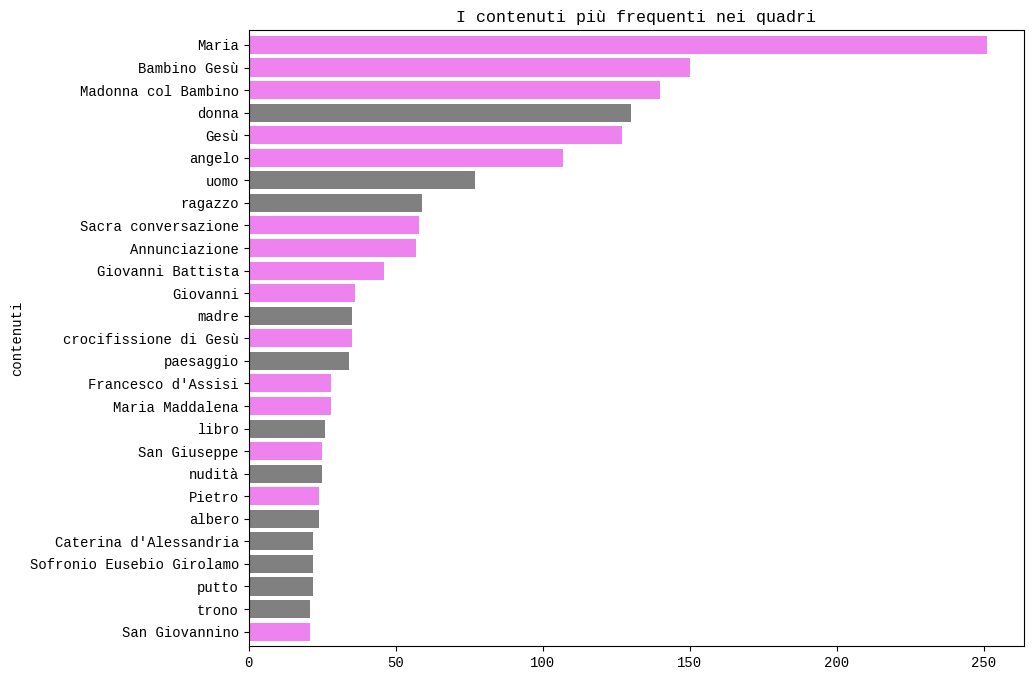

In [162]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Liberation Mono']

frequenza_contenuti = df2['contenuti'].str.split("; ").explode().value_counts().sort_values()
frequenza_contenuti[frequenza_contenuti > 20].plot.barh(
    title="I contenuti più frequenti nei quadri",
    fontsize= 10,
    width=0.8,
    figsize=(10, 8),
    color=["violet","grey","grey","grey","grey","grey","violet","grey","violet","grey","violet","violet","grey","violet","grey","violet","violet","violet","violet","grey","grey","violet","violet","grey","violet","violet","violet"]
    )

Come si può vedere dal grafico, prevalgono **temi religiosi** (evidenziati in viola).
Il contenuto che ha la più alta frequenza è **Maria**.

Adesso facciamo la stessa operazione nella colonna `generi`

In [163]:
df2["generi"].str.split("; ").explode()

,generi
0,ritratto
1,nudo artistico
1,pittura mitologica
2,ritratto
2,ritratto di gruppo
...,...
2439,pittura mitologica
2440,ritratto
2441,arte di genere
2442,arte religiosa


In [164]:
df2["generi"].str.split("; ").explode().value_counts()

,count
generi,
arte religiosa,821
ritratto,441
pittura mitologica,75
arte di genere,53
autoritratto,42
nudo artistico,23
pittura storica,21
pittura paesaggistica,19
allegoria,19


<Axes: title={'center': 'i generi più diffusi'}, ylabel='generi'>

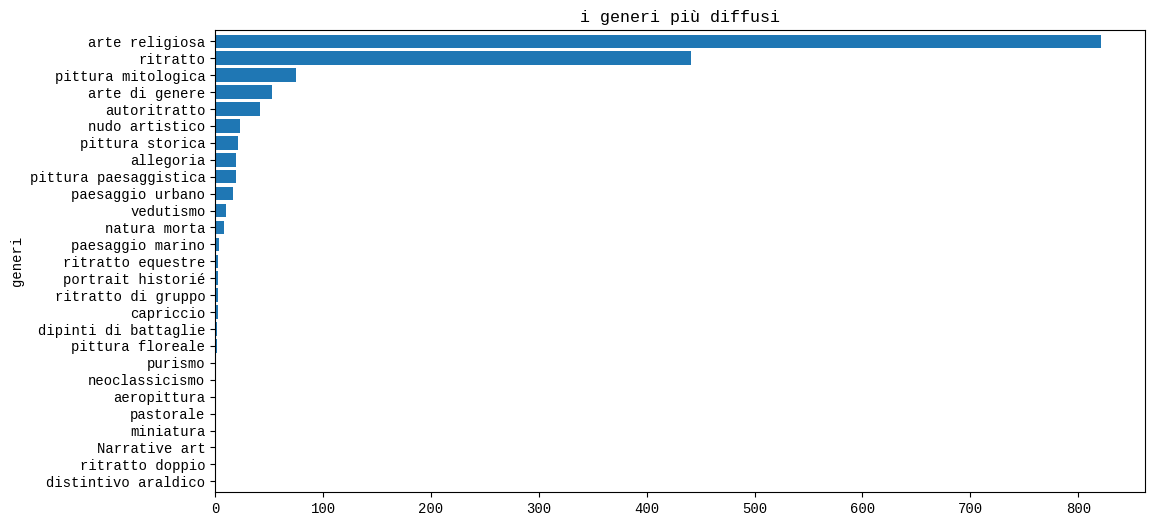

In [165]:
df2["generi"].str.split("; ").explode().value_counts().sort_values().plot.barh(
        figsize=(12, 6),
        fontsize= 10,
        width=0.8,
        title= "i generi più diffusi")

Come sospettavamo, i**l genere più diffuso è arte religiosa** e al secondo posto c'è il ritratto.

Il terzo posto spetta alla pittura mitologica, seguita da arte di genere e autoritratto.

### 4.2 Sempre troppe poche donne

Andiamo ora ad analizzare la presenza di artiste donne all'interno del dataset, nella colonna `artisti`

In [166]:
artiste_donne = df2[df2['artisti'].str.contains('femmina', case=False, na=False)]
artiste_donne


,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,link,id_number
6,Giuditta con la sua ancella,Artemisia Gentileschi (femmina),1610,arte religiosa,Palazzo Pitti,Galleria Palatina,Giuditta e Oloferne; Giuditta,NaN,Giuditta e Oloferne,114.0,93.5,http://www.wikidata.org/entity/Q532486,532486
346,Autoritratto nello studio,Lavinia Fontana (femmina),1579,autoritratto,Corridoio Vasariano,Palazzo degli Uffizi; Corridoio Vasariano,Lavinia Fontana,NaN,Lavinia Fontana,NaN,NaN,http://www.wikidata.org/entity/Q19390001,19390001
350,Autoritratto di Elisabeth Luisa Vigée-Le Brun,Élisabeth Vigée Le Brun (femmina),1790,autoritratto,Palazzo degli Uffizi,Palazzo degli Uffizi,Élisabeth Vigée Le Brun,NaN,Élisabeth Vigée Le Brun,100.0,81.0,http://www.wikidata.org/entity/Q19361572,19361572
398,Donna con turbante,Ginevra Cantofoli (femmina),1650,ritratto,Galleria nazionale d'arte antica,Galleria nazionale d'arte antica,turbante; Beatrice Cenci; donna giovane,NaN,Beatrice Cenci,64.5,49.0,http://www.wikidata.org/entity/Q28113316,28113316
405,Ritratto di neonata nella culla,Lavinia Fontana (femmina),1583,ritratto,Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna,neonato,NaN,NaN,113.0,126.0,http://www.wikidata.org/entity/Q29997042,29997042
406,Ritratto di Paolo Morigia,Fede Galizia (femmina),1593,ritratto,Pinacoteca Ambrosiana,Pinacoteca Ambrosiana,Paolo Morigia,manierismo,Paolo Morigia,88.0,79.0,http://www.wikidata.org/entity/Q29654663,29654663
408,Betsabea,Artemisia Gentileschi (femmina),1640,nudo artistico; arte di genere; arte religiosa,Italia,NaN,donna; nudità; albero; mammella; palazzo; perl...,NaN,Betsabea al bagno,288.0,228.0,http://www.wikidata.org/entity/Q29015025,29015025
424,Susanna e i vecchioni,Onofrio Palumbo (maschio); Artemisia Gentilesc...,1652,arte religiosa,Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna,Susanna e i vecchioni,NaN,Susanna e i vecchioni,NaN,NaN,http://www.wikidata.org/entity/Q30605361,30605361
436,Compianto sul Cristo morto,Plautilla Nelli (femmina),1560,arte religiosa,Museo di San Marco,Museo di San Marco,Gesù,manierismo,Compianto sul Cristo morto,288.0,192.0,http://www.wikidata.org/entity/Q45361473,45361473
472,Autoritratto con ombrello verde,Elisabeth Chaplin (femmina),1907,autoritratto,Galleria d'arte moderna di Firenze,Galleria d'arte moderna di Firenze,Elisabeth Chaplin,NaN,Elisabeth Chaplin,89.0,60.0,http://www.wikidata.org/entity/Q52155641,52155641


In [167]:
artiste_donne.shape

(36, 13)

In [168]:
print(artiste_donne['artisti'].duplicated().value_counts())

artisti
False    25
True     11
Name: count, dtype: int64


Il numero di artiste donne presenti in questo dataset è molto basso, quindi ci aspettiamo dei dati molto limitati.

In ogni caso, che tipo di contenuti sono più frequenti nelle opere delle artiste donne?

<Axes: title={'center': 'I contenuti più frequenti nelle donne'}, ylabel='contenuti'>

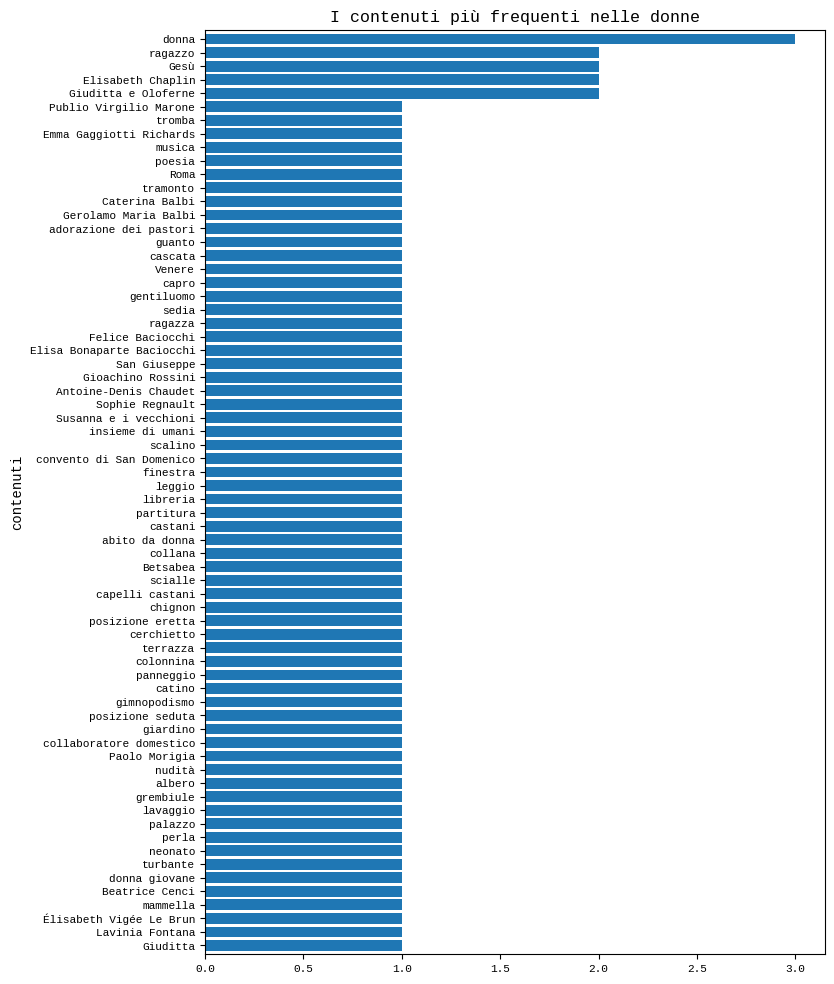

In [169]:
frequenza_contenuti_donne = artiste_donne['contenuti'].str.split("; ").explode().value_counts().sort_values()
frequenza_contenuti_donne[frequenza_contenuti_donne > 0].plot.barh(
    title="I contenuti più frequenti nelle donne",
    fontsize= 8,
    width=0.8,
    figsize=(8, 12),
    )

I contenuti più presenti sono "**donna**", "**Gesù**" e "**ragazzo**", gli stessi argomenti che troviamo **tra i primi 10** in assoluto del dataset.
Possiamo notare in generale la presenza di soggetti femminili e di oggetti che richiamano il mondo femminile (es. guanto, chignon, mammella, abito da donna, scialle, cerchietto, etc.)

### 4.3 La produzione artistica negli anni e nei movimenti

Ora analizziamo l'andamento della produzione artistica nel periodo storico compreso in questo dataset.

<Axes: title={'center': 'La produzione artistica negli anni'}, xlabel='data_creazione'>

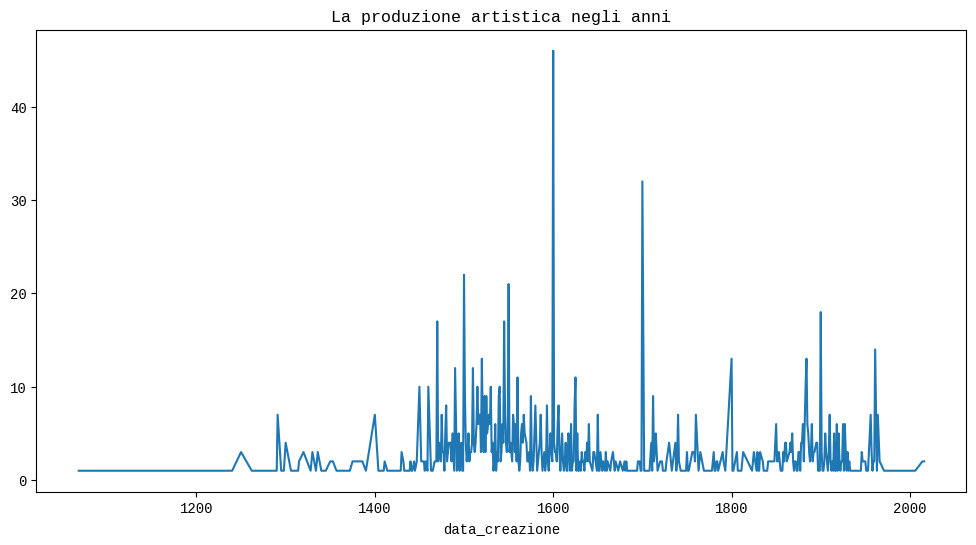

In [170]:
df2['data_creazione'].value_counts().sort_index().plot.line(
  title="La produzione artistica negli anni",
   figsize=(12,6)
    )

Il periodo in cui c'è una più alta produzione artistica è il **1600**.
Stranisce il fatto che il grafico parta da prima del 1200.

Controlliamo se è presente una data prima di quell'anno.

In [171]:
df2_filtrato = df2[(df2['data_creazione'] <= 1200)]
df2_filtrato

,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,link,id_number
1483,Annunciazione,Girolamo Dente (maschio),1068,arte religiosa,Gallerie dell'Accademia,Gallerie dell'Accademia,Annunciazione,NaN,Annunciazione,NaN,NaN,http://www.wikidata.org/entity/Q131450125,131450125


Il dato "1068" nella data di creazione è errato, dal momento che l'artista è nato a inizio 1500 (1510-1568)

Andiamo adesso ad analizzare la colonna `movimenti`, per avere ulteriore conferma (o smentita) su quanto abbiamo scoperto finora.

In [172]:
df2["movimenti"].str.split("; ").explode().value_counts()

,count
movimenti,
pittura veneta,105
Alto Rinascimento,65
manierismo,47
Primo Rinascimento,43
pittura rinascimentale italiana,30
barocco,27
protorinascimento,15
rinascimento italiano,13
realismo,12


<Axes: title={'center': 'I movimenti più diffusi'}, ylabel='movimenti'>

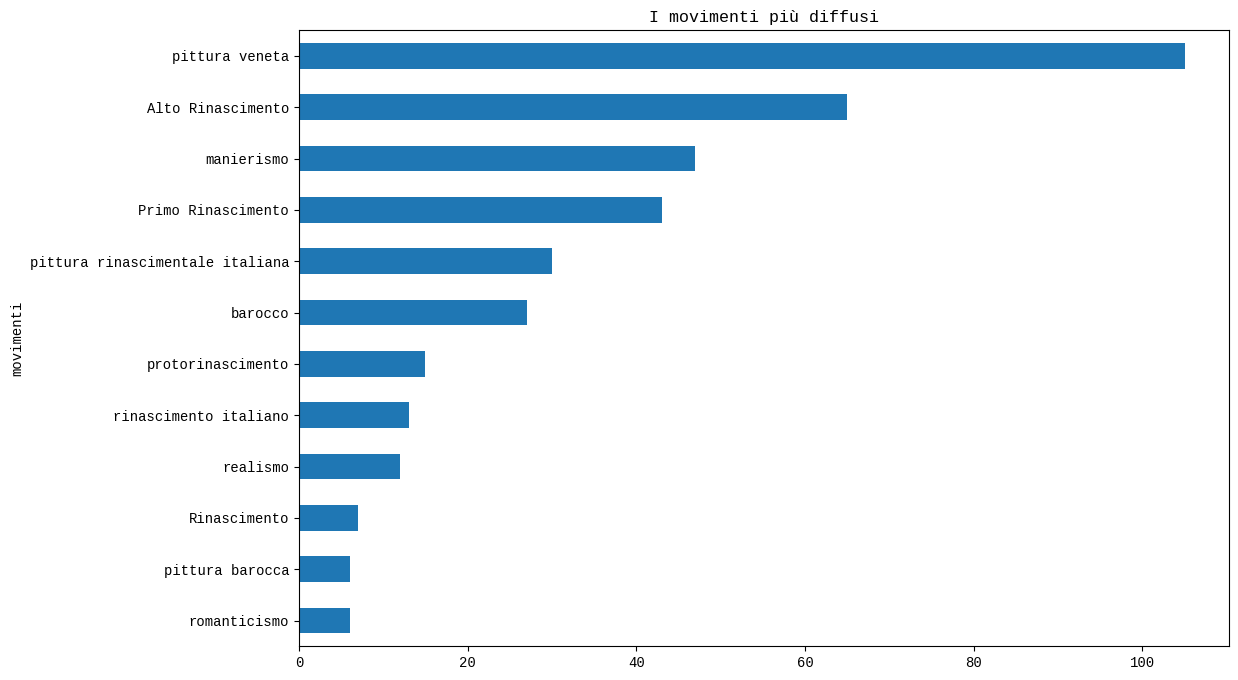

In [173]:
frequenza_movimenti = df2["movimenti"].str.split("; ").explode().value_counts().sort_values()
frequenza_movimenti[frequenza_movimenti > 5].plot.barh(
    title="I movimenti più diffusi",
    fontsize= 10,
    figsize=(12, 8),
    )

I 5 movimenti più diffusi sono: pittura veneta, Alto Rinascimento, manierismo, Primo Rinascimento e pittura rinascimentale italiana.
Ci aspettavamo una posto più in alto per il Barocco, visto quanto scoperto nella precedente domanda, ma per il resto torna abbastanza con i nostri dati.

#5. Analisi esplicativa

Passiamo alla nostra ricerca.

Ci focalizzeremo  in particolare sul rapporto tra contenuti presenti nelle opere e il loro anno di creazione e sulla correlazione tra genere artistico e movimento storico.

## 5.1 C'è una correlazione tra contenuti e l'anno di creazione dell'opera?

La domanda è abbastanza ovvia; sicuramente c'è correlazione.

In [174]:
produzione_seicento = df2[(df2['data_creazione'] >= 1600) & (df2['data_creazione'] <= 1699)]


In [175]:
frequenza_produzione_seicento = produzione_seicento['contenuti'].str.split("; ").explode().value_counts()
print(frequenza_produzione_seicento)

contenuti
Gesù                          24
uomo                          18
Maria                         16
angelo                        15
donna                         13
                              ..
turibolo                       1
Compianto sul Cristo morto     1
angelo custode                 1
Metterza                       1
negromante                     1
Name: count, Length: 350, dtype: int64


<Axes: title={'center': 'Contenuti più frequenti nel 1600'}>

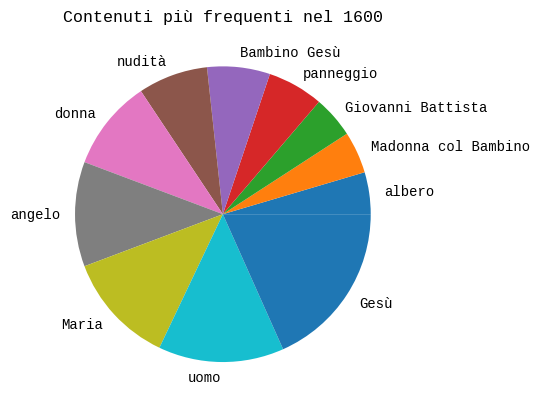

In [176]:
frequenza_produzione_seicento[frequenza_produzione_seicento > 5].sort_values().plot.pie(
    title="Contenuti più frequenti nel 1600",
    ylabel='')

Come ci immaginavamo, nel 1600 prevalgono ancora tematiche religiose. **Maria** e **Gesù** rimangono i soggetti più rappresentati.

Proviamo ora ad analizzare un altro secolo, il XIX secolo.

In [177]:
produzione_ottocento = df2[(df2['data_creazione'] >= 1800) & (df2['data_creazione'] <= 1899)]

In [178]:
frequenza_produzione_ottocento = produzione_ottocento['contenuti'].str.split("; ").explode().value_counts()
print(frequenza_produzione_ottocento)

contenuti
donna                     11
uomo                       7
umano                      6
trono                      4
papa Pio VIII              4
                          ..
disillusione               1
interno                    1
tavole su cui scrivere     1
bouquet di fiori           1
Antonio Agliardi           1
Name: count, Length: 268, dtype: int64


<Axes: title={'center': 'Contenuti più frequenti nel 1800'}>

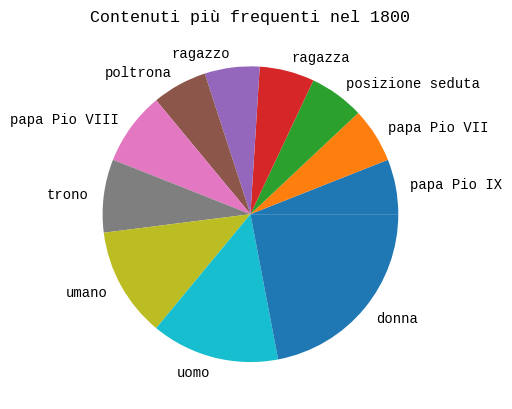

In [179]:
frequenza_produzione_ottocento[frequenza_produzione_ottocento > 2].sort_values().plot.pie(
    title="Contenuti più frequenti nel 1800",
    ylabel=''
    )

Come si può vedere dal grafico, sono diminuiti fortemente i soggetti religiosi come Maria, Gesù, Angeli o simili. Sono rimasti delle rappresentazioni di Papi, ma a livello di contenuti prevalgono riferimenti a esseri umani (umano, uomo, donna, ragazzo, ragazza).

Questi dati confermano ciò che già sappiamo sulla storia (e storia dell'arte). Nel 1800 l'arte religiosa non scompare del tutto, ma diminuisce significativamente rispetto ai secoli precedenti per diversi motivi:
*   l'Illuminismo del '700 aveva diffuso un pensiero più razionale e laico, riducendo l'influenza della Chiesa sulla cultura;
*   la borghesia emergente commissiona soprattutto ritratti, paesaggi e scene di vita quotidiana;
*   Nuovi movimenti artistici: Romanticismo, Realismo e poi Impressionismo si concentrano su natura, emozioni e vita moderna;
*   Riduzione del potere della Chiesa — specialmente dopo la Rivoluzione Francese, la Chiesa perde molto del suo ruolo come principale mecenate dell'arte.

##5.2 Questa correlazione è confermata trai generi e i movimenti più diffusi?

Per capire la correlazione tra movimenti e generi più gettonati, procederemo in questo modo:
*   Preparazione dei dati: Esploderemo le colonne 'generi' e 'movimenti' per gestire le voci multiple e isoleremo i 10 generi e movimenti più frequenti.
*   Tabella di Correlazione: Creeremo una tabella che mostri la frequenza con cui ciascun genere appare con ciascun movimento.
*   Visualizzazione: Utilizzeremo una mappa di calore (heatmap) per visualizzare questa correlazione, rendendo facile identificare le combinazioni più comuni.



Per analizzare la correlazione tra i generi e i movimenti, è necessario prima identificare quelli più diffusi.

Successivamente, creeremo una tabella di contingenza e una mappa di calore per visualizzare la loro co-occorrenza.

In [180]:
import seaborn as sns

In [181]:
df_exploded = df2.assign(generi=df2['generi'].str.split('; ')).explode('generi')
df_exploded = df_exploded.assign(movimenti=df_exploded['movimenti'].str.split('; ')).explode('movimenti')

In [182]:
df_exploded = df_exploded.dropna(subset=['generi', 'movimenti'])

In [183]:
top_10_generi = df_exploded['generi'].value_counts(dropna=False).head(10).index
top_10_movimenti = df_exploded['movimenti'].value_counts().head(10).index


In [184]:
df_filtered_correlation = df_exploded[
    df_exploded['generi'].isin(top_10_generi) &
    df_exploded['movimenti'].isin(top_10_movimenti)
]


In [185]:
correlation_table = pd.crosstab(df_filtered_correlation['generi'], df_filtered_correlation['movimenti'])

In [186]:
print("Tabella di correlazione tra i 10 generi e i 10 movimenti più diffusi:")
display(correlation_table)

Tabella di correlazione tra i 10 generi e i 10 movimenti più diffusi:


movimenti,Alto Rinascimento,Primo Rinascimento,Rinascimento,barocco,manierismo,pittura rinascimentale italiana,pittura veneta,protorinascimento,realismo,rinascimento italiano
generi,,,,,,,,,,
allegoria,2,4,0,2,3,0,2,0,0,0
arte di genere,0,0,0,0,0,1,1,0,8,0
arte religiosa,40,29,4,19,14,11,58,13,0,11
autoritratto,0,0,0,0,1,0,1,0,0,0
nudo artistico,1,1,1,0,3,0,4,0,0,0
pittura mitologica,3,6,1,1,4,1,13,0,0,0
pittura storica,1,0,0,1,0,1,0,0,1,0
ritratto,19,5,2,4,26,16,32,2,4,1


La tabella di correlazione mostra quante volte ciascun genere appare in associazione con ciascun movimento. Ora visualizziamo questi dati con una mappa di calore per una migliore comprensione.

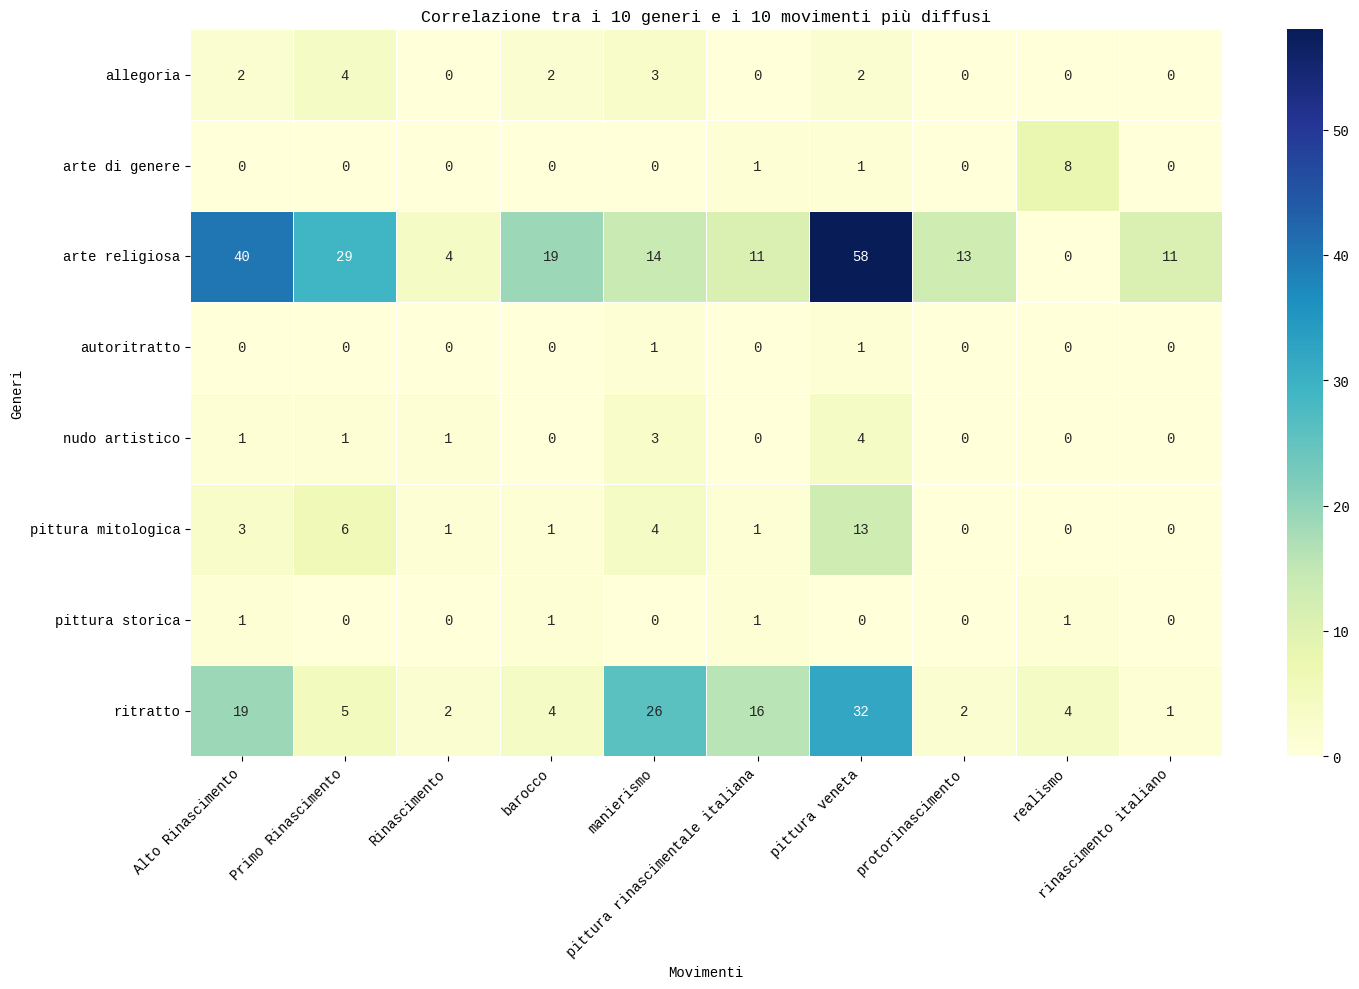

In [187]:
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_table, annot=True, cmap='YlGnBu', fmt='g', linewidths=.5)
plt.title('Correlazione tra i 10 generi e i 10 movimenti più diffusi')
plt.xlabel('Movimenti')
plt.ylabel('Generi')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Anche questa analisi ha confermato la forte presenza di tematiche religiose nel corso della storia dell'arte.
Inoltre abbiamo scoperto (ma forse un pò lo sapevamo già) che anche il ritratto è un genere ricorrente.
Abbiamo inoltre avuto la conferma che dopo il 1700/1800 i temi religiosi vanno esaurendosi, come possiamo vedere nel movimento ***"realismo"***.

#6. Conclusioni

L'analisi conferma, con un approccio quantitativo, una trasformazione storicamente nota: il passaggio da un'arte a prevalenza religiosa a una più incentrata sull'uomo e sulla vita quotidiana nell'Ottocento, riflesso dei cambiamenti sociali e culturali dell'epoca. Questa tendenza è confermata sia dall'analisi dei contenuti che da quella dei generi e movimenti artistici.

Lo studio presenta tuttavia alcuni limiti: il dataset, pur ampio, non rappresenta l'intero patrimonio artistico ed è soggetto a possibili bias di catalogazione; inoltre, la classificazione dei contenuti in categorie predefinite semplifica inevitabilmente la complessità interpretativa propria di ogni opera.
Nonostante ciò, l'analisi mostra come i dati possano offrire una conferma empirica a tendenze già note alla storia dell'arte, integrando l'approccio critico tradizionale con una prospettiva quantitativa.